# Confronto tra Insertion Sort e Bubble Sort

> Lorenzo Malavolti (Matricola 7048432)
>
> Università degli studi di Firenze
>
> Laboratorio di Algoritmi, Esercizio B

## Introduzione
Lo scopo di questo notebook è confrontare le prestazioni di due algoritmi di ordinamento: Insertion Sort e Bubble Sort.
>
Per semplicità, si suppone che le liste da ordinare contengano solo numeri interi anche se gli algoritmi funzionano con qualsiasi tipo di dato ordinabile (ad esempio stringhe o date).


## Cenni Teorici
### Problema dell'ordinamento
Data una sequenza di n elementi, l'obiettivo è riordinarli in modo crescente (o decrescente) secondo un criterio di ordinamento definito.

### Insertion Sort
L'Insertion Sort è un algoritmo di ordinamento che costruisce l'ordinamento finale un elemento alla volta. Per ogni elemento, lo confronta con quelli già ordinati e lo inserisce nella posizione corretta. In particolare, sposta gli elementi più grandi di una posizione a destra per fare spazio al nuovo elemento.

<div align="center">
    <img src="https://upload.wikimedia.org/wikipedia/commons/3/32/Insertionsort-before.png"
         alt="Schema Insertion Sort prima dell'iterazione">
         <br>
    <small><i>(Fig. 1): Stato dell'array prima di un'iterazione dell'Insertion Sort.</i></small>
</div>

<div align="center">
    <img src="https://upload.wikimedia.org/wikipedia/commons/d/d9/Insertionsort-after.png"
         alt="Schema Insertion Sort dopo iterazione">
         <br>
    <small><i>(Fig. 1): Stato dell'array prima di un'iterazione dell'Insertion Sort.</i></small>
</div>

### Complessità
Questo algoritmo ha una complessità temporale di $O(n^2)$ nel caso peggiore (quando la lista è ordinata in modo decrescente) e $\Omega(n)$ nel caso migliore (quando la lista è già ordinata). Nel caso medio, la complessità è $O(n^2)$.

<div align="center">

| Caso Migliore | Caso Medio | Caso Peggiore |
|:-------------:|:----------:|:-------------:|
|  $\Omega(n)$  |  $O(n^2)$  |   $O(n^2)$    |
</div>

Dalle complessità sopra riportate, vediamo che questo algoritmo è particolarmente efficiente per liste già ordinate o quasi ordinate, ma diventa inefficiente per liste di grandi dimensioni che sono in ordine inverso.

### Esempi
<div align="center">
    <img src="https://upload.wikimedia.org/wikipedia/commons/0/0f/Insertion-sort-example-300px.gif"
         height="150px"
         alt="Schema Insertion Sort dopo iterazione">
         <br>
</div>

In [23]:
#Insertion Sort
def insertion_sort(A: list):
    for i in range(1, len(A)):
        key = A[i]
        j = i - 1
        while j >= 0 and key < A[j]:
            A[j + 1] = A[j]
            j -= 1
        A[j + 1] = key

### Bubble Sort
Il Bubble Sort è un algoritmo di ordinamento semplice che ripetutamente scorre la lista, confronta elementi adiacenti e li scambia se sono nell'ordine sbagliato. Il processo viene ripetuto fino a quando la lista è ordinata.

### Complessità
Il Bubble Sort ha una complessità temporale di $O(n^2)$ sia nel caso peggiore che nel caso medio, e $O(n)$ nel caso migliore (quando la lista è già ordinata). Tuttavia, senza l'ottimizzazione con un flag, il Bubble Sort rimane $O(n^2)$ anche nel caso migliore.

<div align="center">

| Caso Migliore | Caso Medio | Caso Peggiore |
|:-------------:|:----------:|:-------------:|
|   $O(n^2)$    |  $O(n^2)$  |   $O(n^2)$    |
</div>

Dalla tabella sopra, vediamo che il Bubble Sort è inefficiente per liste di grandi dimensioni, indipendentemente dall'ordinamento iniziale.

### Esempi
<div align="center">
    <img src="https://upload.wikimedia.org/wikipedia/commons/c/c8/Bubble-sort-example-300px.gif"
         height="150px"
         alt="Schema Bubble Sort dopo iterazione">
         <br>
</div>

In [ ]:
#Bubble Sort
def bubble_sort_cormen(A):
    n = len(A)
    for i in range(n):
        # Il ciclo interno fa risalire l'elemento più piccolo
        for j in range(n - 1, i, -1):
            if A[j] < A[j - 1]:
                A[j], A[j - 1] = A[j - 1], A[j]

In [22]:
import time
import random
import matplotlib.pyplot as plt
import platform

# Fissiamo il seed per rendere l'esperimento riproducibile
random.seed(42)

# Informazioni sull'ambiente di esecuzione
print(f"Sistema Operativo: {platform.system()} {platform.release()}")
print(f"Processore: {platform.processor()}")
print("-" * 30)

Sistema Operativo: Windows 11
Processore: Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
------------------------------


In [24]:
def run_benchmark(algorithm, data):
    # Usiamo una copia per non sporcare i dati per l'algoritmo successivo
    arr_copy = data.copy()
    start_time = time.perf_counter() # Più preciso di time.time()
    algorithm(arr_copy)
    return time.perf_counter() - start_time

# Configurazioni del test
sizes = [100, 250, 500, 750, 1000, 1250]
results = {
    "bubble_random": [], "insertion_random": [],
    "bubble_sorted": [], "insertion_sorted": [],
    "bubble_reverse": [], "insertion_reverse": []
}

for n in sizes:
    # Generazione dei casi
    random_case = [random.randint(0, 10000) for _ in range(n)]
    sorted_case = sorted(random_case)
    reverse_case = sorted_case[::-1]

    # Esecuzione test
    results["bubble_random"].append(run_benchmark(bubble_sort_cormen, random_case))
    results["insertion_random"].append(run_benchmark(insertion_sort, random_case))

    results["bubble_sorted"].append(run_benchmark(bubble_sort_cormen, sorted_case))
    results["insertion_sorted"].append(run_benchmark(insertion_sort, sorted_case))

    results["bubble_reverse"].append(run_benchmark(bubble_sort_cormen, reverse_case))
    results["insertion_reverse"].append(run_benchmark(insertion_sort, reverse_case))

print("Benchmark completato!")

Benchmark completato!


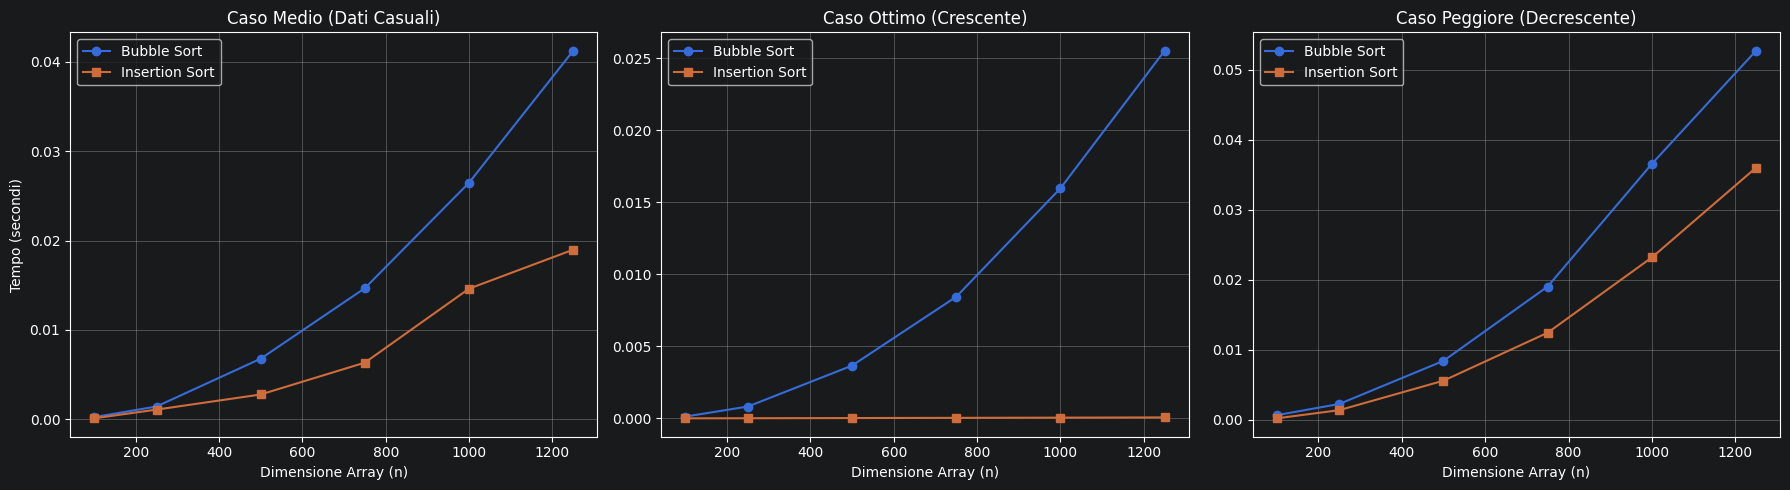

In [25]:
plt.figure(figsize=(18, 5))

# Grafico 1: Caso Medio (Casuale)
plt.subplot(1, 3, 1)
plt.plot(sizes, results["bubble_random"], 'o-', label='Bubble Sort')
plt.plot(sizes, results["insertion_random"], 's-', label='Insertion Sort')
plt.title("Caso Medio (Dati Casuali)")
plt.xlabel("Dimensione Array (n)")
plt.ylabel("Tempo (secondi)")
plt.legend()
plt.grid(True)

# Grafico 2: Caso Ottimo (Già Ordinato)
plt.subplot(1, 3, 2)
plt.plot(sizes, results["bubble_sorted"], 'o-', label='Bubble Sort')
plt.plot(sizes, results["insertion_sorted"], 's-', label='Insertion Sort')
plt.title("Caso Ottimo (Crescente)")
plt.xlabel("Dimensione Array (n)")
plt.legend()
plt.grid(True)

# Grafico 3: Caso Peggiore (Decrescente)
plt.subplot(1, 3, 3)
plt.plot(sizes, results["bubble_reverse"], 'o-', label='Bubble Sort')
plt.plot(sizes, results["insertion_reverse"], 's-', label='Insertion Sort')
plt.title("Caso Peggiore (Decrescente)")
plt.xlabel("Dimensione Array (n)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()